In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

In [101]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
plt.rcParams['axes.edgecolor'] = '0.0'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Sizes
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2.2

# Tick parameters
plt.rcParams['xtick.top'] = 'False'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.minor.visible'] = 'True'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.left'] = 'True'
plt.rcParams['ytick.right'] = 'False'
plt.rcParams['ytick.minor.visible'] = 'True'
plt.rcParams['ytick.direction'] = 'out'

plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['xtick.minor.size'] = 9/4
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['ytick.major.size'] = 3
plt.rcParams['ytick.minor.size'] = 9/4

In [102]:
df_props = pd.read_csv("host_props.csv")
df_reliable = pd.read_csv('all_parameters_reliable.csv').rename(columns={'objname':'transient'})
df_ddlr = pd.read_csv('titan_ddlr.csv').rename(columns={'objname':'transient'})
print(len(df_props))
df_props = df_props.merge(df_ddlr[['transient', 'd_dlr']], on='transient', how='left')
df_props = df_props[df_props['transient'].isin(df_reliable['transient']) & df_props['d_dlr'].le(10)]
print(len(df_props))

9361
8610


In [7]:
list_of_CIDs = []
with h5py.File("/Volumes/S-Express/TITAN/SN_age_samples.h5", "r") as f:
    keys = list(f.keys())
    first = f[keys[0]]
    list_of_age_samples = np.empty((len(keys),) + first.shape, dtype=np.float32)
    for i, key in enumerate(keys):
        list_of_CIDs.append(key)
        f[key].read_direct(list_of_age_samples[i])

In [8]:
# limit dada to good CIDs only
CIDs_good = df_props['transient'].values
CID_mask = np.isin(list_of_CIDs, CIDs_good)
list_of_age_samples = list_of_age_samples[CID_mask]
list_of_CIDs = np.array(list_of_CIDs)[CID_mask]

(-0.1, 2.0)

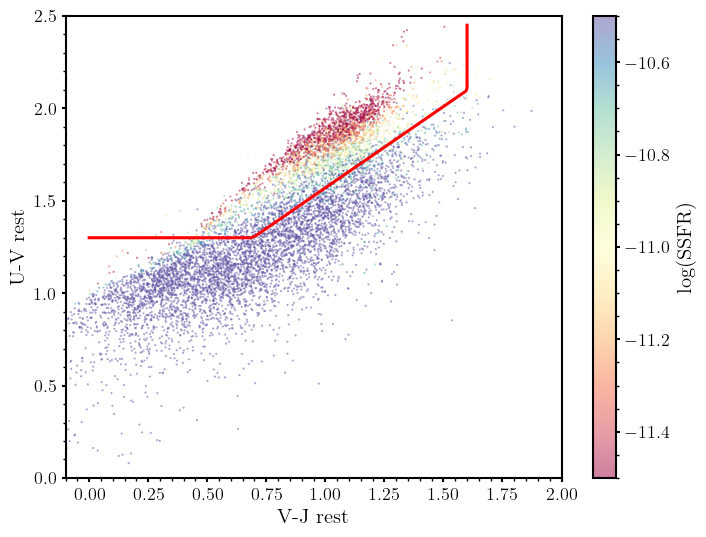

In [27]:
def is_Quiescent(uv,vj):
    return (vj<1.6) & (uv>1.3) & (uv>0.88*vj+0.69)

def is_StarForming(uv,vj):
    return ~(uv>0.88*vj+0.69)
    
# plot the boundary line
vj = np.linspace(0, 2, 100)
uv = 0.88*vj + 0.69
uv = np.maximum(uv, 1.3)  # Ensure uv is at least 1.3
vj = np.minimum(vj, 1.6)  # Ensure vj is at most (uv - 0.69) / 0.88

plt.figure(figsize=(8,6))
plt.plot(vj, uv, color='red', label='Boundary Line')
    
sc = plt.scatter(df_props['vj_colour_50'],df_props['uv_colour_50'], s=0.3, alpha=0.5,c=df_props['ssfr_50'], cmap='Spectral',vmin=-11.5,vmax=-10.5)
plt.colorbar(sc, label='log(SSFR)')
plt.xlabel('V-J rest')
plt.ylabel('U-V rest')
plt.ylim(0,2.5)
plt.xlim(-0.1,2)

Text(0.5, 1.0, 'UVJ split')

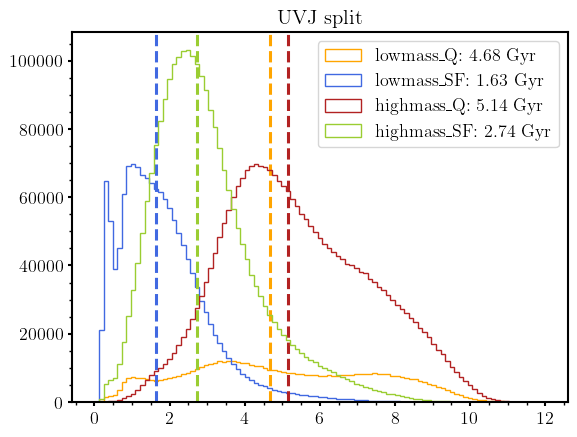

In [14]:
# split by UVJ

lowmass_Q = df_props['stellar_mass_50'].le(10) & is_Quiescent(df_props['uv_colour_50'], df_props['vj_colour_50'])
lowmass_SF = df_props['stellar_mass_50'].le(10) & is_StarForming(df_props['uv_colour_50'], df_props['vj_colour_50'])
highmass_Q = df_props['stellar_mass_50'].gt(10) & is_Quiescent(df_props['uv_colour_50'], df_props['vj_colour_50'])
highmass_SF = df_props['stellar_mass_50'].gt(10) & is_StarForming(df_props['uv_colour_50'], df_props['vj_colour_50'])

names = ["lowmass_Q", "lowmass_SF", "highmass_Q", "highmass_SF"]
colors = ['orange','royalblue','firebrick','yellowgreen']
masks = [lowmass_Q, lowmass_SF, highmass_Q, highmass_SF]

bins = np.linspace(0,12,100)
for mask, name, color in zip(masks, names, colors):
    CID_mask = np.isin(list_of_CIDs, df_props['transient'][mask])
    _sample_means = list_of_age_samples[CID_mask].mean(axis=2)
    
    plt.hist(np.ravel(_sample_means), bins=bins, 
             color=color, histtype='step', label=name+f': {np.median(_sample_means):.2f} Gyr');
    plt.axvline(np.median(_sample_means), color=color, linestyle='--')
plt.legend();
plt.title(f'UVJ split')


In [31]:
_pdf = list_of_age_samples[:,::10,:]
_ev = list_of_age_samples.mean(axis=2)

<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/713418450.py:35: SyntaxWarning: invalid escape sequence '\%'
  _twinx.set_xticklabels([f'{p}\%' for p in np.arange(25,101,25)])
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/713418450.py:36: SyntaxWarning: invalid escape sequence '\m'
  _twinx.set_xlabel('Percentiles of $t_\mathrm{prog}$')


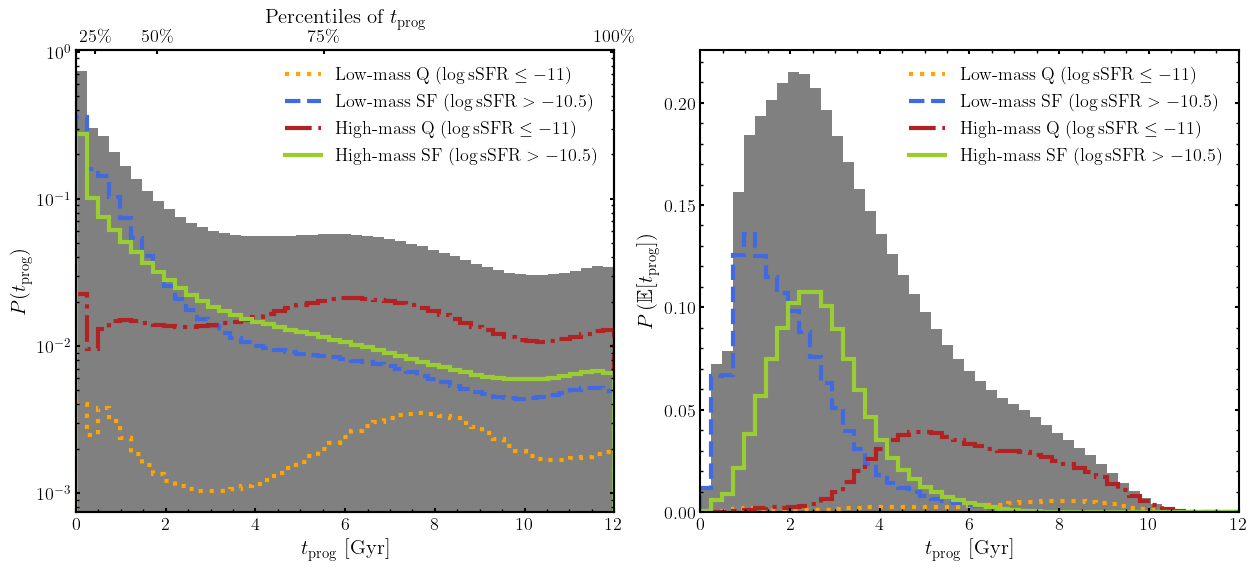

In [76]:
# split by sSFR (intermediate population removed)

lowmass_Q = df_props['stellar_mass_50'].le(10) & df_props['ssfr_50'].le(-11)
lowmass_SF = df_props['stellar_mass_50'].le(10) & df_props['ssfr_50'].gt(-10.5)
highmass_Q = df_props['stellar_mass_50'].gt(10) & df_props['ssfr_50'].le(-11)
highmass_SF = df_props['stellar_mass_50'].gt(10) & df_props['ssfr_50'].gt(-10.5)

names = [r"Low-mass Q ($\log\mathrm{sSFR} \le -11$)", r"Low-mass SF ($\log\mathrm{sSFR} > -10.5$)", r"High-mass Q ($\log\mathrm{sSFR} \le -11$)", r"High-mass SF ($\log\mathrm{sSFR} > -10.5$)"]
colors = ['orange','royalblue','firebrick','yellowgreen']
masks = [lowmass_Q, lowmass_SF, highmass_Q, highmass_SF]

fig,axes = plt.subplots(1,2,figsize=(15,6))
plt.subplots_adjust(wspace=0.16)
bins = np.linspace(0,12,50)

# normalize to density
counts_pdf, edges = np.histogram(np.ravel(_pdf), bins=bins)
counts_ev, _ = np.histogram(np.ravel(_ev), bins=bins)
norm1 = len(np.ravel(_pdf)) * np.diff(edges)
norm2 = len(np.ravel(_ev)) * np.diff(edges)
axes[0].stairs(counts_pdf/norm1, edges, color='gray',fill=True)
axes[1].stairs(counts_ev/norm2, edges, color='gray', fill=True)

for mask, name, color, ls in zip(masks, names, colors, [':', '--', '-.', '-']):
    CID_mask = np.isin(list_of_CIDs, df_props['transient'][mask])

    _counts_pdf = np.histogram(np.ravel(_pdf[CID_mask]), bins=bins)[0]
    _counts_ev = np.histogram(np.ravel(_ev[CID_mask]), bins=bins)[0]
    axes[0].stairs(_counts_pdf/norm1, edges, color=color, label=name,lw=3,ls=ls)
    axes[1].stairs(_counts_ev/norm2, edges, color=color, label=name,lw=3,ls=ls)

_twinx = axes[0].twiny()
_twinx.set_xlim(0,12)
_twinx.set_xticks(np.nanpercentile(_pdf, np.arange(25,101,25)))
_twinx.set_xticklabels([f'{p}\%' for p in np.arange(25,101,25)])
_twinx.set_xlabel('Percentiles of $t_\mathrm{prog}$')
_twinx.minorticks_off()
_twinx.set_yticks([])
_twinx.tick_params(direction='in')
axes[0].set_xlim(0,12)
axes[0].set_yscale('log')
axes[1].set_xlim(0,12)
axes[0].set_ylabel(r'$P(t_\mathrm{prog})$',fontsize=15)
axes[1].set_ylabel(r'$P\left(\mathbb{E}[t_\mathrm{prog}]\right)$',fontsize=15)
axes[0].legend(frameon=False);
axes[1].legend(frameon=False);

axes[0].tick_params(which='both', direction='in', top=False, right=True)
axes[1].tick_params(which='both', direction='in', top=True, right=True)
for ax in axes:
    ax.set_xlabel(r'$t_\mathrm{prog}$ [Gyr]',fontsize=15)
plt.savefig('figures/progenitor_age_histogram.pdf', bbox_inches='tight')
# plt.title(f'Q: log(sSFR) <= -11, SF: log(SSFR) > -10.5')

### calculate age difference between subpopulations

In [78]:

list_of_age_samples.mean(axis=2).mean(axis=0).shape


(1000,)

In [82]:
from scipy.stats import gaussian_kde
# x_th = 
for mask, name, color in zip(masks, names, colors):
    CID_mask = np.isin(list_of_CIDs, df_props['transient'][mask])
    _sample_means = list_of_age_samples[CID_mask].mean(axis=2).mean(axis=0)
    lower,median,upper = np.percentile(_sample_means, [16,50,84])
    print(f'{name}: {median:.2f} Gyr (+{upper-median:.2f}/-{median-lower:.2f})')
# plt.legend()

Low-mass Q ($\log\mathrm{sSFR} \le -11$): 6.40 Gyr (+0.08/-0.08)
Low-mass SF ($\log\mathrm{sSFR} > -10.5$): 1.97 Gyr (+0.01/-0.01)
High-mass Q ($\log\mathrm{sSFR} \le -11$): 6.03 Gyr (+0.02/-0.02)
High-mass SF ($\log\mathrm{sSFR} > -10.5$): 2.71 Gyr (+0.01/-0.01)


In [85]:
diff_HM_Q_SF = 6.03-2.71
diff_HM_Q_SF_err = np.sqrt(0.02**2 + 0.01**2)
sigma_dev = (diff_HM_Q_SF*0.03 - 0.028)/np.sqrt(0.022**2 + (0.03*diff_HM_Q_SF_err)**2)
print(f'sigma deviation between our age measurement + S25 model vs. W26 HR values: {sigma_dev:.2f}')
# 0.028 ± 0.022

sigma deviation between our age measurement + S25 model vs. W26 HR values: 3.25


# galaxy age vs. SN age

In [86]:
# compute mean expectation value of age samples and add to df_props
for CID, age in zip(list_of_CIDs, list_of_age_samples.mean(axis=2)):
    df_props.loc[df_props['transient'] == CID, 'prog_age_16'] = np.nanpercentile(age, 16)
    df_props.loc[df_props['transient'] == CID, 'prog_age_50'] = np.median(age)
    df_props.loc[df_props['transient'] == CID, 'prog_age_84'] = np.nanpercentile(age, 84)

In [87]:
df_props.to_csv("host_props_with_SN_age_good_Mar18.csv", index=False)

/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/2574841305.py:4: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(df_props['prog_age_50'][_mask], df_props['mass_weighted_age_50'][_mask], deg=6)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/2574841305.py:4: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(df_props['prog_age_50'][_mask], df_props['mass_weighted_age_50'][_mask], deg=6)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/2574841305.py:4: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(df_props['prog_age_50'][_mask], df_props['mass_weighted_age_50'][_mask], deg=6)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/2574841305.py:4: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(df_props['prog_age_50'][_mask], df_props['mass_weighted_age_50'][_mask], deg=6)
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/2574841305.

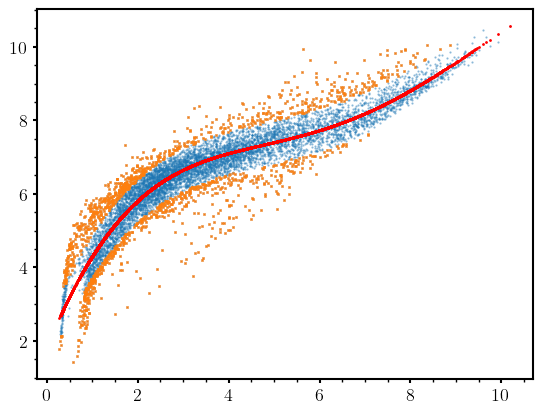

In [89]:
# iteratively fit polynomial with outlier rejection
_mask = np.ones(len(df_props), dtype=bool)
for _ in range(5):
    coeffs = np.polyfit(df_props['prog_age_50'][_mask], df_props['mass_weighted_age_50'][_mask], deg=6)
    poly = np.poly1d(coeffs)
    residuals = df_props['mass_weighted_age_50'] - poly(df_props['prog_age_50'])
    std_resid = np.std(residuals[_mask])
    _mask = np.abs(residuals) < 2*std_resid

tprog_to_tmwa = poly(df_props['prog_age_50'])
plt.scatter(df_props['prog_age_50'], df_props['mass_weighted_age_50'], s=0.3, alpha=0.5)
plt.scatter(df_props['prog_age_50'][~_mask], df_props['mass_weighted_age_50'][~_mask], s=0.3, marker='x')
plt.scatter(df_props['prog_age_50'], tprog_to_tmwa, color='red', label='Polynomial Fit',s=1)

/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/3966116095.py:24: UserWarning: You passed a edgecolor/edgecolors ('yellowgreen') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_props['mass_weighted_age_50'][mask], df_props['prog_age_50'][mask], s=ms,
/var/folders/hf/dh49zz3n1x5d1p_b4qn8g4z00000gn/T/ipykernel_90766/3966116095.py:26: UserWarning: You passed a edgecolor/edgecolors ('yellowgreen') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_bot.scatter(df_props['mass_weighted_age_50'][mask],


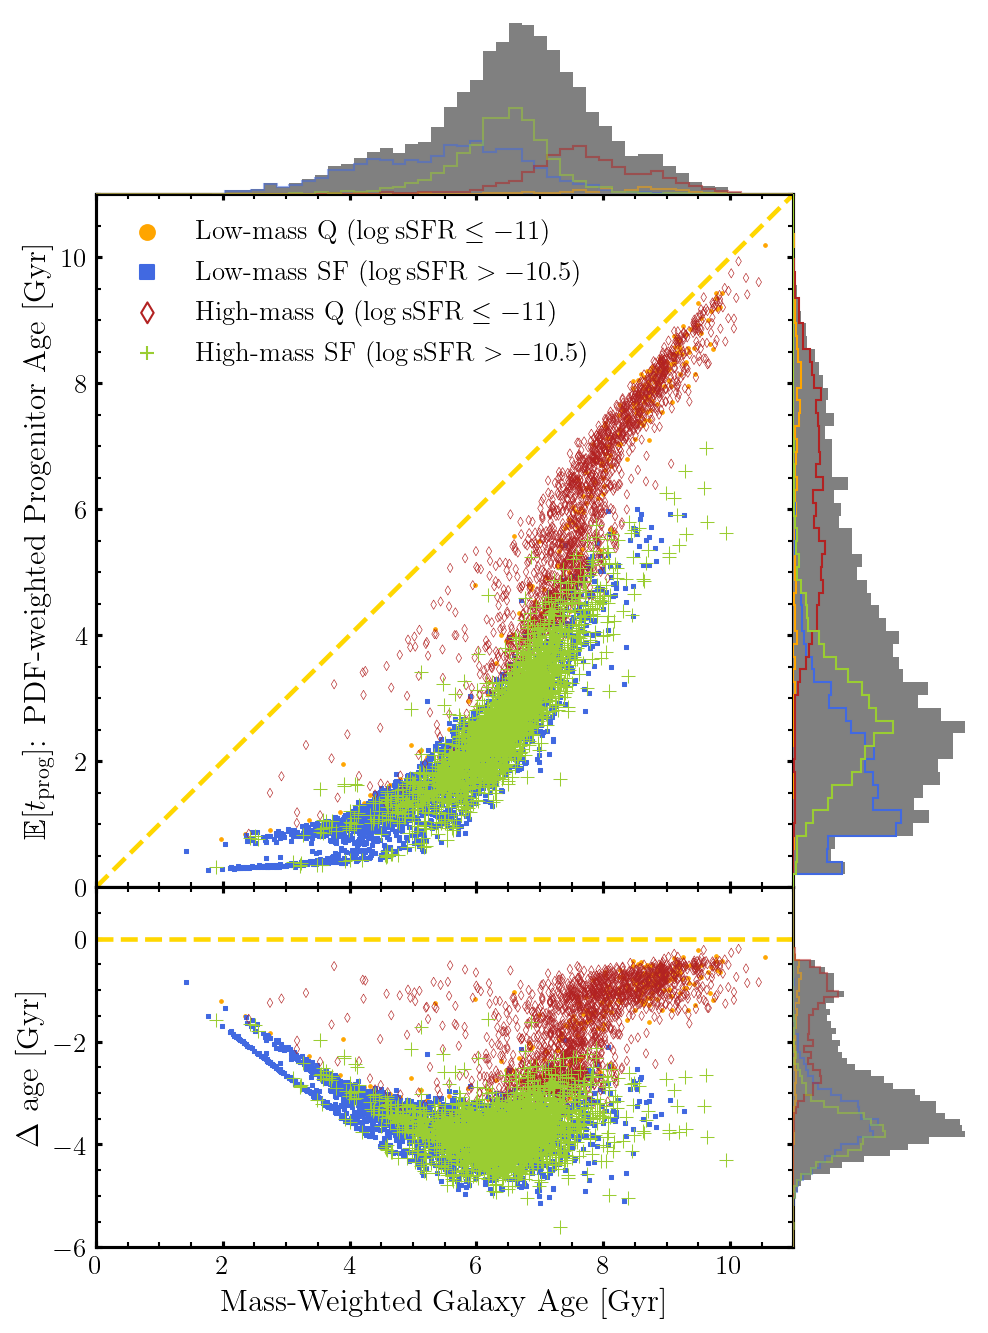

In [97]:
df_props['age_diff'] = df_props['prog_age_50'] - df_props['mass_weighted_age_50']

fig,ax = plt.subplots(1,1,figsize=(6,6),dpi=150)
pos = ax.get_position().bounds
ax_bot = fig.add_axes([pos[0], pos[1]-0.4, pos[2], 0.4])
ax_top = fig.add_axes([pos[0], pos[1]+pos[3], pos[2], 0.2])
ax_right = fig.add_axes([pos[0]+pos[2], pos[1], 0.2, pos[3]])
ax_botright = fig.add_axes([pos[0]+pos[2], pos[1]-0.4, 0.2, 0.4])


# histograms
age_bins = np.linspace(0,12,60)
diff_bins = np.linspace(-6,1,60)
ax_right.hist(df_props['prog_age_50'], bins=age_bins, orientation='horizontal', color='gray')
ax_top.hist(df_props['mass_weighted_age_50'], bins=age_bins, color='gray')
ax_botright.hist(df_props['age_diff'], bins=diff_bins, color='gray',orientation='horizontal')

for mask, name, color,marker,ms,noFC,lw in zip(
    masks, names, colors, 
    ['o','s','d','+'], 
    [3,3,10,50],
    [False,False,True,False],
    [0.5,0.5,0.3,0.5]):
    ax.scatter(df_props['mass_weighted_age_50'][mask], df_props['prog_age_50'][mask], s=ms, 
                alpha=1, label=name, ec=color, fc='none' if noFC else color, marker=marker, lw=lw)
    ax_bot.scatter(df_props['mass_weighted_age_50'][mask], 
                   df_props['age_diff'][mask], s=ms,
                alpha=1, label=name, ec=color, fc='none' if noFC else color, marker=marker, lw=lw)
    
    # add histograms of each population to the marginal axes
    ax_right.hist(df_props['prog_age_50'][mask], bins=age_bins, orientation='horizontal', color=color, histtype='step')
    ax_top.hist(df_props['mass_weighted_age_50'][mask], bins=age_bins, color=color, alpha=0.5, histtype='step')
    ax_botright.hist(df_props['age_diff'][mask], bins=diff_bins, color=color, alpha=0.5, orientation='horizontal', histtype='step')
    
    
leg = ax.legend(frameon=False, fontsize=13)
# set marker size in legend
for handle in leg.legend_handles:
    handle.set_sizes([50])  
    handle.set_linewidth(1)

ax.set_ylabel(r'$\mathbb{E}[t_\mathrm{prog}]$: PDF-weighted Progenitor Age [Gyr]', fontsize=15)
ax_bot.set_xlabel('Mass-Weighted Galaxy Age [Gyr]', fontsize=15)
ax_bot.set_ylabel(r'$\Delta$ age [Gyr]', fontsize=15)
ax.plot([0,12],[0,12],c='gold',ls='--')
ax.set_ylim(0,11)
ax.set_xlim(0,11)
ax.tick_params(which='both',direction='in', top=True, right=True)
ax.set_xticklabels([])


ax_top.axis('off')
ax_right.axis('off')
ax_botright.axis('off')
ax_top.set_xlim(ax.get_xlim())
ax_right.set_ylim(ax.get_ylim())
ax_bot.set_xlim(ax.get_xlim())
ax_bot.set_ylim(-6,1)
ax_botright.set_ylim(-6,1)
ax_bot.set_yticks(np.arange(-6,1,2))
ax_bot.tick_params(which='both',direction='in', top=True, right=True)
ax_bot.axhline(0, c='gold', ls='--')
plt.savefig('figures/tSN_vs_tGal.pdf', bbox_inches='tight')
# plt.scatter(df_props['prog_age'], df_props['mass_weighted_age_50'], s=1, alpha=0.5,)

# redshift dependency: TODO with Phil's data

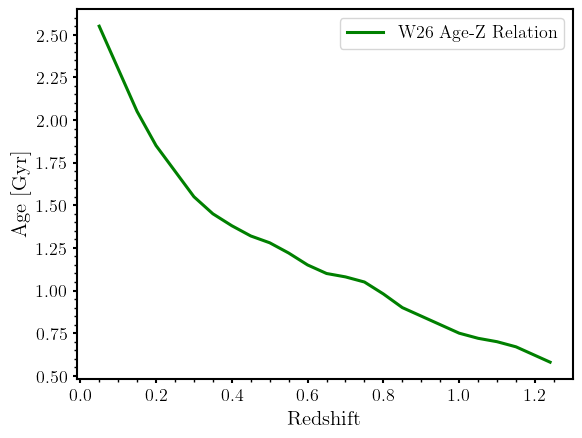

In [99]:
W26_z = [
    0.050, 0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400, 0.450,
    0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800, 0.850, 0.900,
    0.950, 1.000, 1.050, 1.100, 1.150, 1.200, 1.240
]

W26_age_gyr = [
    2.55, 2.30, 2.05, 1.85, 1.70, 1.55, 1.45, 1.38, 1.32,
    1.28, 1.22, 1.15, 1.10, 1.08, 1.05, 0.98, 0.90, 0.85,
    0.80, 0.75, 0.72, 0.70, 0.67, 0.62, 0.58
]
W26_z = np.array(W26_z)
W26_age_gyr = np.array(W26_age_gyr)
plt.plot(W26_z, W26_age_gyr, color='green', label='W26 Age-Z Relation')
plt.xlabel('Redshift')
plt.ylabel('Age [Gyr]')
plt.legend()
plt.show()

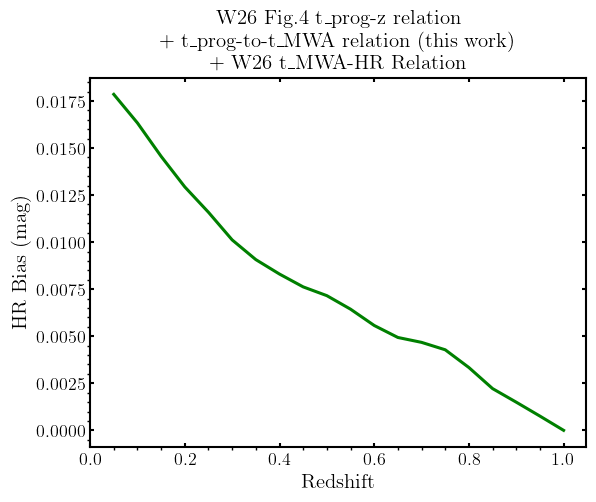

In [100]:
HR_bias = np.array(poly(W26_age_gyr)*0.007)
HR_bias -= HR_bias[np.argmin(np.abs(W26_z-1))]
HR_bias[W26_z>1] = np.nan
plt.plot(W26_z, HR_bias, color='green', label='')
plt.xlim(0,)
plt.xlabel('Redshift', fontsize=15)
plt.ylabel('HR Bias (mag)',fontsize=15)
plt.title('W26 Fig.4 t_prog-z relation\n+ t_prog-to-t_MWA relation (this work)\n+ W26 t_MWA-HR Relation')
plt.gca().tick_params(direction='in',top=True,right=True)